# CNN for RadioML Dataset

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Load the RadioML2016 dataset
with open('RML2016.10a_dict.pkl', 'rb') as f:
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    p = u.load()

# Extract SNRs and modulation types
snrs, mods = map(lambda j: sorted(list(set(map(lambda x: x[j], p.keys())))), [1,0])

In [5]:
X = []
lbl = []
for mod in mods:
    for snr in snrs:
        X.append(p[(mod,snr)])
        for i in range(p[(mod,snr)].shape[0]):
            lbl.append((mod,snr))

X = np.vstack(X)

In [ ]:
np.random.seed(2016)
n_examples = int(X.shape[0])
n_train = int(n_examples * 0.7)
train_idx = np.random.choice(range(0,n_examples), size=n_train, replace=False)
test_idx = list(set(range(0,n_examples))-set(train_idx))
X_train = X[train_idx]
X_test = X[test_idx]

def to_onehot(yy):
    yy1 = np.zeros([len(yy), max(yy)+1])
    yy1[np.arange(len(yy)),yy] = 1
    return yy1

Y_train = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), train_idx)))
Y_test = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), test_idx)))

# After creating Y_train and Y_test, convert to class indices
Y_train_indices = np.argmax(Y_train, axis=1)
Y_test_indices = np.argmax(Y_test, axis=1)

# Convert to PyTorch tensors
X_train_torch = torch.FloatTensor(X_train).unsqueeze(1)
X_test_torch = torch.FloatTensor(X_test).unsqueeze(1)
Y_train_torch = torch.LongTensor(Y_train_indices)
Y_test_torch = torch.LongTensor(Y_test_indices)

In [7]:
print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Classes: {mods}')

Training data shape: (154000, 2, 128)
Test data shape: (66000, 2, 128)
Classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [8]:
batch_size = 1024
train_dataset = TensorDataset(X_train_torch, Y_train_torch)
test_dataset = TensorDataset(X_test_torch, Y_test_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class RadioMLCNN(nn.Module):
    def __init__(self, num_classes=11, dropout_rate=0.5):
        super(RadioMLCNN, self).__init__()

        # Convolutional layers
        self.pad1 = nn.ZeroPad2d((1, 1, 0, 0))
        self.conv1 = nn.Conv2d(1, 256, kernel_size=(1, 3), padding=0)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.pad2 = nn.ZeroPad2d((2, 2, 0, 0))
        self.conv2 = nn.Conv2d(256, 80, kernel_size=(2, 3), padding=0)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Dense layers
        self.flatten_size = 80 * 1 * 130
        self.fc1 = nn.Linear(self.flatten_size, 256)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, num_classes)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.pad1(x)
        x = F.relu(self.conv1(x))
        x = self.dropout1(x)

        x = self.pad2(x)
        x = F.relu(self.conv2(x))
        x = self.dropout2(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)

        return x  # Return logits

In [10]:
# Initialize model
model = RadioMLCNN(num_classes=len(mods), dropout_rate=0.5).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

RadioMLCNN(
  (pad1): ZeroPad2d((1, 1, 0, 0))
  (conv1): Conv2d(1, 256, kernel_size=(1, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.5, inplace=False)
  (pad2): ZeroPad2d((2, 2, 0, 0))
  (conv2): Conv2d(256, 80, kernel_size=(2, 3), stride=(1, 1))
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=10400, out_features=256, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=11, bias=True)
)

Total parameters: 2789467
Trainable parameters: 2789467


In [11]:
criterion = nn.CrossEntropyLoss()
# Y_train_torch = torch.LongTensor(np.argmax(Y_train, axis=1))  # Shape: (N,) indices
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

In [14]:
# Train the model
num_epochs = 50
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print('\nStarting training...')
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')


Starting training...
Epoch [2/50], Train Loss: 1.9919, Train Acc: 25.63%, Test Loss: 1.8724, Test Acc: 28.46%
Epoch [4/50], Train Loss: 1.7990, Train Acc: 31.66%, Test Loss: 1.7021, Test Acc: 34.74%
Epoch [6/50], Train Loss: 1.6560, Train Acc: 37.66%, Test Loss: 1.5269, Test Acc: 43.20%
Epoch [8/50], Train Loss: 1.5384, Train Acc: 41.64%, Test Loss: 1.4081, Test Acc: 45.48%
Epoch [10/50], Train Loss: 1.4803, Train Acc: 43.35%, Test Loss: 1.3661, Test Acc: 46.54%
Epoch [12/50], Train Loss: 1.4445, Train Acc: 44.46%, Test Loss: 1.3365, Test Acc: 48.09%
Epoch [14/50], Train Loss: 1.4202, Train Acc: 45.26%, Test Loss: 1.3398, Test Acc: 47.90%
Epoch [16/50], Train Loss: 1.4016, Train Acc: 45.89%, Test Loss: 1.3309, Test Acc: 47.82%
Epoch [18/50], Train Loss: 1.3927, Train Acc: 46.17%, Test Loss: 1.2928, Test Acc: 49.33%
Epoch [20/50], Train Loss: 1.3840, Train Acc: 46.61%, Test Loss: 1.2947, Test Acc: 49.26%
Epoch [22/50], Train Loss: 1.3784, Train Acc: 46.63%, Test Loss: 1.3016, Test Acc:

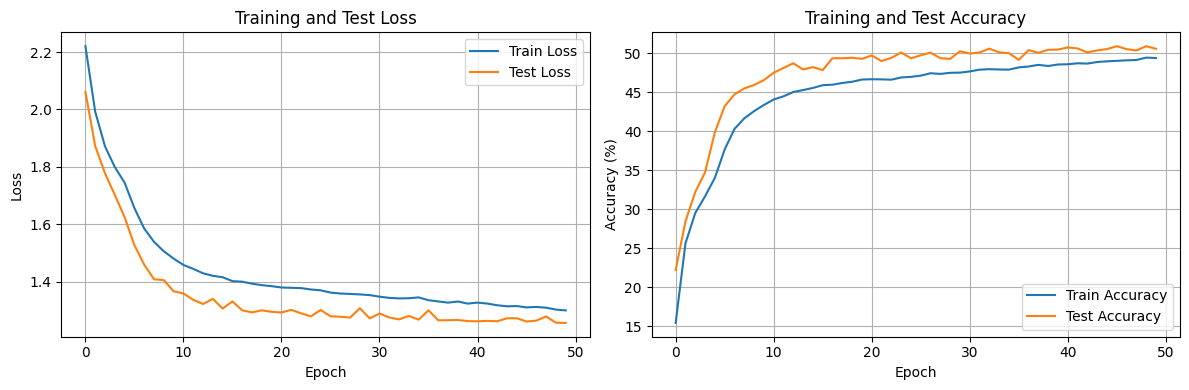


Final Test Accuracy: 50.55%
Model saved to radioml_cnn_pytorch.pth


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(test_accs, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFinal Test Accuracy: {test_accs[-1]:.2f}%')

# Save the model
torch.save(model.state_dict(), 'radioml_cnn_pytorch.pth')
print('Model saved to radioml_cnn_pytorch.pth')
